# PyToch Convolutional Neural Network Training

-   If use google collaborant, run inside yolo_mps_v11

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import random_split, DataLoader

import matplotlib.pyplot as plt
import numpy as np

import copy

print("imports ok!")

imports ok!


In [2]:
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")          # Apple Silicon GPU
    elif torch.cuda.is_available():
        return torch.device("cuda")         # NVIDIA GPU
    else:
        return torch.device("cpu")          # Fallback

device = get_device()
print("Using device:", device)

Using device: cpu


## Formula to calculate output size
__(N+F+2P) / S+1__ where:
-   N = activation
-   F = kernel
-   S = strike
-   P = padding

Calculation of volumes:
- Convolution1: 
    - padding = 0, 
    - stride = 1
    - input = 32
    - kernel = 5
    - spatial size = ((32 - 5 + 0)/1) + 1 = 28
    - output = output channels x spatial size^2 
    - output = (6 x 28 x 28)

- Max pool (2x2)
    - Spatial size = 28/2 = 14
    - output = output channels x spatial size^2 
    - output (6 x 14 x 14)

- Convolution 2: 
    - no padding, stride 1
    - Spatial size = ((14-5+0)/1)+1 = 10
    - output = output channels x spatial size^2 
    - output (16 x 10 x 10)

- Max pool (2x2)
    - Spatial size = 10 / 2 = 5
    - output (16 x 5 x 5)
  
- Flatten
    - 16 x 5 x 5 = 400 input to fully connected layer

In [3]:
# define neural network
class Net(nn.Module):
    def __init__(self, grayscale=False):
        super(Net, self).__init__() # constructor

        # first layer is CNN
        self.grayscale = grayscale
        if grayscale:
            # Input image 32x32x1, 6 output channels, 5x5 convolution
            self.conv1 = nn.Conv2d(1, 6, 5)
        else:
            # Input image 32x32x3, 6 output channels, 5x5 convolution
            self.conv1 = nn.Conv2d(3, 6, 5)

        # second layer is CNN
        # params: in-channels, out-channels, kernel-size
        self.conv2 = nn.Conv2d(6, 16, 5)

        # final layer3 are fully connected ANN (not CNN)
        self.fc1 = nn.Linear( 16 * 5 * 5, 120)
        self.fc2 = nn.Linear( 120, 84)
        self.fc3 = nn.Linear( 84, 10)

    # define forward callback function
    def forward(self, x):
        # conv layer c1: 
        #       1/3 input image channels,
        #       6 output channels
        #       5x5 kernel, ReLu
        #       outputs: Tensor (N, 6, 28, 28)
        #       N means batch size, needed because we do not update weights 
        #       all the time but after a batch
        cv1 = F.relu(self.conv1(x))

        # sumbsampling layer ss2: 
        # 2x2 grid, stride 2
        # subsampling => reduce size of activation map
        # outputs: (N, 6, 14, 14)
        # where N = batch, 6 = layers, 14 = x, 14 = y
        ss2 = F.max_pool2d(cv1, (2,2))

        # convolution layer C3: 
        # 6 input channels, 16 output channels
        # 5x5 kernel, ReLU
        # outputs: (N, 16, 10, 10)
        cv3 = F.relu(self.conv2(ss2))

        # Subsampling layer SS4: 
        # 2x2 grid, stride 2
        # subsampling => reduce size of activation map
        # outputs: (N, 16, 5, 5)
        ss4 = F.max_pool2d(cv3, (2,2))

        # flatten (16 * 5 * 5) = 400
        ss4f = torch.flatten(ss4, 1)

        # Fully connected layer FC5:
        # inputs (N, 400) 
        # outputs: (N, 120) with ReLu
        fcl5 = F.relu(self.fc1(ss4f))

        # Fully connected layer FCL6: 
        # inputs (N, 120) with ReLu
        # outputs (N, 84) with ReLu
        fcl6 = F.relu(self.fc2(fcl5))

        # Fully connected layer FCL6
        # inputs (N, 120) with ReLu
        # outputs (N, 84) with ReLu
        fcl6 = F.relu(self.fc2(fcl5))

        # Fully connected layer FCL7
        # inputs (N, 120) with ReLu
        # outputs (N, 10)
        fcl7 = self.fc3(fcl6)

        return fcl7

# Create CNN network with GPU
net = Net().to(device)
print(f"{net} using {device}")


Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
) using cpu


In [4]:
def InitializeDataLoaders(batch_size=4, model_save_path='./data', grayscale=False):
    # Crete pipeline using Compose
    if grayscale:
        # use transforms.compose to build a pipeline with python list
        transform = transforms.Compose([
            # we need to verify that gray image is not 3 channels that just looks gray
            # but a real 1 channel gray image
            transforms.Grayscale(num_output_channels=1),
            # send data to GPU/CPU and scale
            transforms.ToTensor(),
            # scale values [-1, 1] with mean 0
            transforms.Normalize
        ])
    else:
        # use transforms.compose to build a pipeline with python list
        transform = transforms.Compose([
            # send data to GPU/CPU and scale
            transforms.ToTensor(),
            # three channels, so make pixels from [0,1] to [-1, 1]
            # x' = ((x-0.5)/0.5)
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    # batch size = 4
    # each iteration over trainloader yields a batch of 4 images + labels
    # => model sees 4 samples at a time, 
    #       the loss/gradients are computed over those 4
    #       then one optimizer step is taken
    trainset = torchvision.datasets.CIFAR10(
        root=model_save_path, 
        train=True, 
        download=True,
        transform=transform)
    
    # remember to shuffle train set data every batch or NN learns the order of images
    trainloader = torch.utils.data.DataLoader(
        trainset, 
        batch_size=batch_size,
        shuffle=True,
        num_workers=2)
    
    # TEST SETS
    testset = torchvision.datasets.CIFAR10(
        root=model_save_path, 
        train=False, 
        download=True,
        transform=transform)
    
    # test data no need shuffle, no matter
    testloader = torch.utils.data.DataLoader(
        trainset, 
        batch_size=batch_size,
        shuffle=False,
        num_workers=2)
    
    return trainloader, testloader

In [5]:
# detectable objects are classified
def DefineClasses():
  classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
  return classes

In [6]:
def TrainNetwork(net, epoch_count, trainloader, optimizer, criterion, device=device):
    history = {
        "epoch_loss": [],
        "epoch_accuracy": []
    }

    best_accuracy = 0.0
    # return state of neural network with dictionary
    best_state_dict = copy.deepcopy(net.state_dict())
    best_epoch = -1

    for epoch in range(epoch_count):
        net.train()

        running_loss = 0.0
        epoch_loss_sum = 0.0
        correct = 0
        total = 0

        # iterate over epoch
        # output: 4x1x32x32 if batch_size=4, grayscale image of 32x32
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device) # name of object type

            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # statistics
            batch_loss = loss.item()
            running_loss += batch_loss
            epoch_loss_sum += batch_loss

            # accumulate  accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item() # was prediction correct or not

            if (i % 2000) ==  1999:
                print(f"Epoch {epoch + 1} batch {i + 1} loss (last 2000 batches): {running_loss/2000:.4f}")
                running_loss = 0.0

        # epoch statistics
        epoch_loss = epoch_loss_sum / max(1, len(trainloader))
        epoch_accuracy = correct / total if total > 0 else 0.0

        history["epoch_loss"].append(epoch_loss)
        history["epoch_accuracy"].append(epoch_accuracy)

        # track best model
        if (epoch_accuracy > best_accuracy):
            best_accuracy = epoch_accuracy
            # return state of neural network with dictionary
            best_state_dict = copy.deepcopy(net.state_dict())
            best_epoch = epoch

        print(f"Epoch {epoch + 1} / {epoch_count}")
        print(f"loss: {epoch_loss:.4f}")
        print(f"accuracy: {epoch_accuracy:.4f}")
        print(f"best so far: {best_epoch}")

    print("Finished training!")
    return history, best_state_dict, best_epoch

In [7]:
def SaveNetworkModel(net, path):
  torch.save(net.state_dict(), path)

In [8]:
# ---- visualize learning curves ----
def VisualizeLearningCurves(history, nbr_of_epochs):
  epochs = range(1, nbr_of_epochs + 1)

  plt.figure(figsize=(10, 4))

  # Loss
  plt.subplot(1, 2, 1)
  plt.plot(epochs, history["epoch_loss"], marker='o')
  plt.title("Training Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.grid(True)

  # Accuracy
  plt.subplot(1, 2, 2)
  plt.plot(epochs, [acc * 100 for acc in history["epoch_accuracy"]], marker='o')
  plt.title("Training Accuracy")
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy (%)")
  plt.grid(True)

  plt.tight_layout()
  plt.show()

In [9]:
def TrainAndSaveModel(
                epoch_count=4, 
                batch_size=4, 
                save_path="./cifar_net.pth", 
                save_best=True,
                device=device):
    cnn = Net()
    cnn.to(device)

    print('Initializing dataloaders')
    trainloader, testloader = InitializeDataLoaders(batch_size)
    classes = DefineClasses()
    print('...classes defined')

    criterion = nn.CrossEntropyLoss()
    # stocastic variant decent for optimizer
    optimizer = optim.SGD(cnn.parameters(), lr=0.001, momentum=0.9)

    print("...criterion and optimizer defined about to train")
    history, best_state_dict, best_epoch = TrainNetwork(cnn, epoch_count, trainloader, optimizer, criterion, device)

    if save_path != None:
        if save_best:
            cnn.load_state_dict(best_state_dict)
            cnn.to(device)

            print(f"saving best model {best_epoch + 1}")
        else:
            print("saving last model")

        # save trained model to harddrive
        SaveNetworkModel(cnn, save_path)

    VisualizeLearningCurves(history, epoch_count)
    return cnn, classes, trainloader, testloader, history

Initializing dataloaders
Files already downloaded and verified
Files already downloaded and verified
...classes defined
...criterion and optimizer defined about to train
Epoch 1 batch 2000 loss (last 2000 batches): 2.2129
Epoch 1 batch 4000 loss (last 2000 batches): 1.8501
Epoch 1 batch 6000 loss (last 2000 batches): 1.6471
Epoch 1 batch 8000 loss (last 2000 batches): 1.5604
Epoch 1 batch 10000 loss (last 2000 batches): 1.4983
Epoch 1 batch 12000 loss (last 2000 batches): 1.4678
Epoch 1 / 12
loss: 1.6956
accuracy: 0.3757
best so far: 0
Epoch 2 batch 2000 loss (last 2000 batches): 1.3932
Epoch 2 batch 4000 loss (last 2000 batches): 1.3666
Epoch 2 batch 6000 loss (last 2000 batches): 1.3644
Epoch 2 batch 8000 loss (last 2000 batches): 1.3392
Epoch 2 batch 10000 loss (last 2000 batches): 1.3177
Epoch 2 batch 12000 loss (last 2000 batches): 1.2841
Epoch 2 / 12
loss: 1.3418
accuracy: 0.5162
best so far: 1
Epoch 3 batch 2000 loss (last 2000 batches): 1.1898
Epoch 3 batch 4000 loss (last 2000

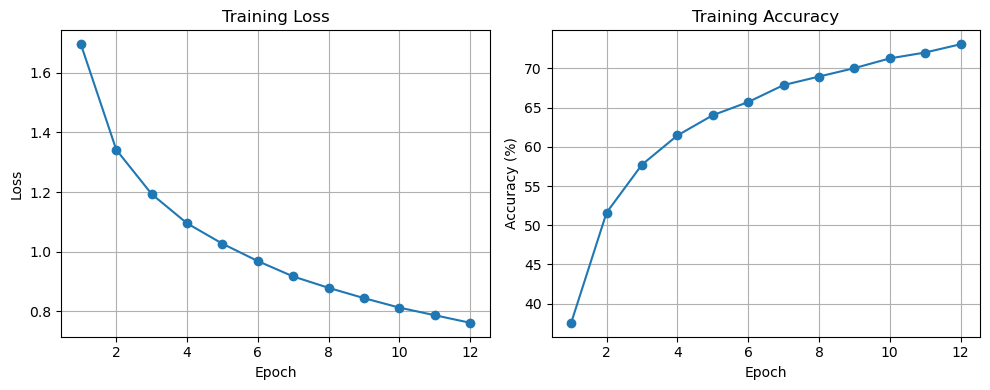

In [10]:
cnn, classes, trainloader, testloader, history = TrainAndSaveModel(epoch_count=12, batch_size=4, )
